In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

In [4]:
df = pd.read_csv('Retail customer_segmentation.csv')

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.shape

(2240, 29)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isna().sum().sum()

np.int64(24)

In [9]:
df.dropna(inplace=True)

In [10]:
df.isna().sum().sum()

np.int64(0)

In [11]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [12]:
df["Education"].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [13]:
df["Marital_Status"].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [14]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst = True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [16]:
df = df.drop_duplicates()
df = df.dropna(subset=["Income"])


In [17]:
df["Monetary"] = (
    df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] +
    df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
)


In [18]:
df["Frequency"] = (
    df["NumWebPurchases"] + df["NumCatalogPurchases"] +
    df["NumStorePurchases"] + df["NumDealsPurchases"]
)

In [19]:
df["Recency"] = df["Recency"]

rfm = df[["ID", "Recency", "Frequency", "Monetary"]]


In [20]:
print(rfm.head())

     ID  Recency  Frequency  Monetary
0  5524       58         25      1617
1  2174       38          6        27
2  4141       26         21       776
3  6182       26          8        53
4  5324       94         19       422


In [21]:
X = rfm[["Recency", "Frequency", "Monetary"]]

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
wcss = []

In [24]:
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

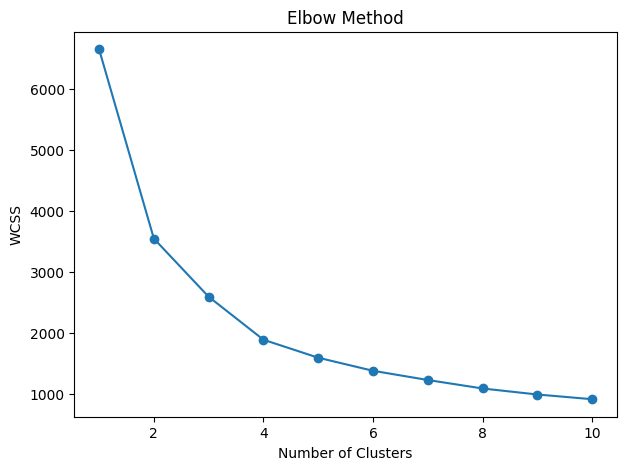

In [25]:
plt.figure(figsize=(7,5))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [27]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print(rfm.head())

     ID  Recency  Frequency  Monetary  Cluster
0  5524       58         25      1617        1
1  2174       38          6        27        0
2  4141       26         21       776        3
3  6182       26          8        53        0
4  5324       94         19       422        1


/tmp/ipykernel_994/314913860.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm["Cluster"] = kmeans.fit_predict(X_scaled)


In [28]:
segment_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "ID": "count"
}).rename(columns={"ID": "Customer_Count"})

In [29]:
print(segment_profile)

           Recency  Frequency     Monetary  Customer_Count
Cluster                                                   
0        24.414191   8.783828   134.026403             606
1        73.016636  21.510166  1147.388170             541
2        74.679443   8.951220   135.099303             574
3        23.129293  21.975758  1142.979798             495


In [30]:
def segment_name(row):
    if row["Monetary"] > rfm["Monetary"].mean() and row["Frequency"] > rfm["Frequency"].mean():
        return "High Value Customers"
    elif row["Recency"] > rfm["Recency"].mean() and row["Frequency"] < rfm["Frequency"].mean():
        return "At Risk Customers"
    elif row["Frequency"] > rfm["Frequency"].mean():
        return "Loyal Customers"
    else:
        return "Low Value Customers"

In [31]:
rfm["Segment_Name"] = rfm.apply(segment_name, axis=1)


/tmp/ipykernel_994/3081739842.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm["Segment_Name"] = rfm.apply(segment_name, axis=1)


In [32]:
print(rfm[["ID", "Recency", "Frequency", "Monetary", "Cluster", "Segment_Name"]].head())

     ID  Recency  Frequency  Monetary  Cluster          Segment_Name
0  5524       58         25      1617        1  High Value Customers
1  2174       38          6        27        0   Low Value Customers
2  4141       26         21       776        3  High Value Customers
3  6182       26          8        53        0   Low Value Customers
4  5324       94         19       422        1       Loyal Customers


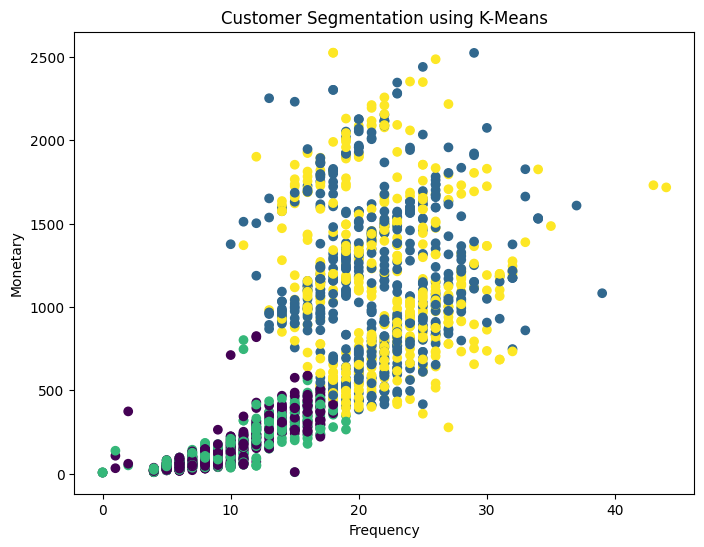

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(rfm["Frequency"], rfm["Monetary"], c=rfm["Cluster"])
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segmentation using K-Means")
plt.show()

In [34]:
rfm.to_csv("Customer_Segmentation_RFM_KMeans.csv", index=False)


In [35]:
print("File saved successfully!")

File saved successfully!
